### Appliance Energy Consumption Prediction

This project aims to analyze and predict energy consumption using environmental and time-based features.

Focus:
- Understanding patterns (EDA)
- Feature relationships
- Building robust ML model

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
import shap


import warnings
warnings.filterwarnings('ignore')

C:\Users\shivj\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Data

In [2]:
df = pd.read_csv('energydata_complete.csv')
df.head()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,11-01-2016 17:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.60,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,11-01-2016 17:10,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.48,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,11-01-2016 17:20,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.37,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,11-01-2016 17:30,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.25,733.8,92.0,6.000000,51.500000,5.0,45.410390,45.410390
4,11-01-2016 17:40,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.13,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


### Shape

In [3]:
df.shape

(19735, 29)

### 📌 Dataset contains thousands of time-based energy observations.

### Info

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         19735 non-null  str    
 1   Appliances   19735 non-null  int64  
 2   lights       19735 non-null  int64  
 3   T1           19735 non-null  float64
 4   RH_1         19735 non-null  float64
 5   T2           19735 non-null  float64
 6   RH_2         19735 non-null  float64
 7   T3           19735 non-null  float64
 8   RH_3         19735 non-null  float64
 9   T4           19735 non-null  float64
 10  RH_4         19735 non-null  float64
 11  T5           19735 non-null  float64
 12  RH_5         19735 non-null  float64
 13  T6           19735 non-null  float64
 14  RH_6         19735 non-null  float64
 15  T7           19735 non-null  float64
 16  RH_7         19735 non-null  float64
 17  T8           19735 non-null  float64
 18  RH_8         19735 non-null  float64
 19  T9           19

### Null Check

In [5]:
df.isnull().sum()

date           0
Appliances     0
lights         0
T1             0
RH_1           0
T2             0
RH_2           0
T3             0
RH_3           0
T4             0
RH_4           0
T5             0
RH_5           0
T6             0
RH_6           0
T7             0
RH_7           0
T8             0
RH_8           0
T9             0
RH_9           0
T_out          0
Press_mm_hg    0
RH_out         0
Windspeed      0
Visibility     0
Tdewpoint      0
rv1            0
rv2            0
dtype: int64

###  No missing values → good quality dataset

# EDA

### Convert Date

In [6]:
 df['date'] = pd.to_datetime(df['date'], dayfirst=True)

### Time Features

In [7]:
df['hour'] = df['date'].dt.hour
df['weekday'] = df['date'].dt.weekday
df['month'] = df['date'].dt.month

### Target Distribution

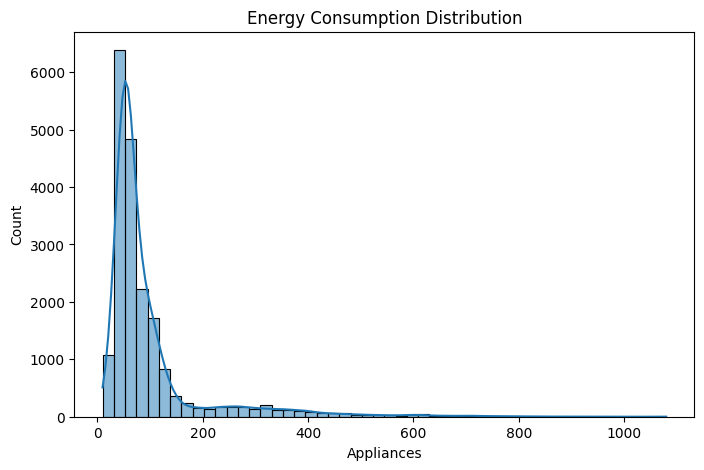

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df['Appliances'], bins=50, kde=True)
plt.title("Energy Consumption Distribution")
plt.show()

### 📌 Energy consumption is right-skewed → some high spikes

## Hour vs Energy

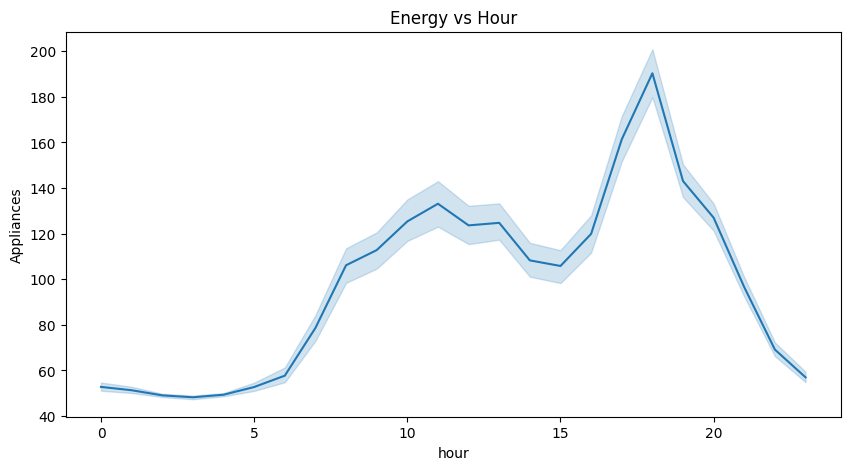

In [9]:
plt.figure(figsize=(10,5))
sns.lineplot(x='hour', y='Appliances', data=df)
plt.title("Energy vs Hour")
plt.show()

### 📌 Peak usage during specific hours (likely evening)

## Weekday vs Energy

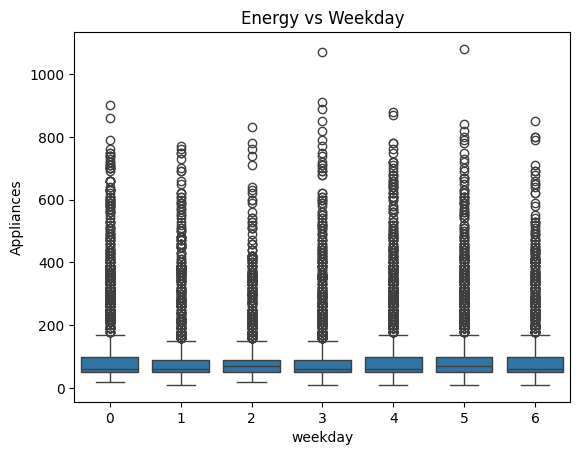

In [10]:
sns.boxplot(x='weekday', y='Appliances', data=df)
plt.title("Energy vs Weekday")
plt.show()

### 📌 Variation across weekdays → behavior pattern

## Temperature vs Energy

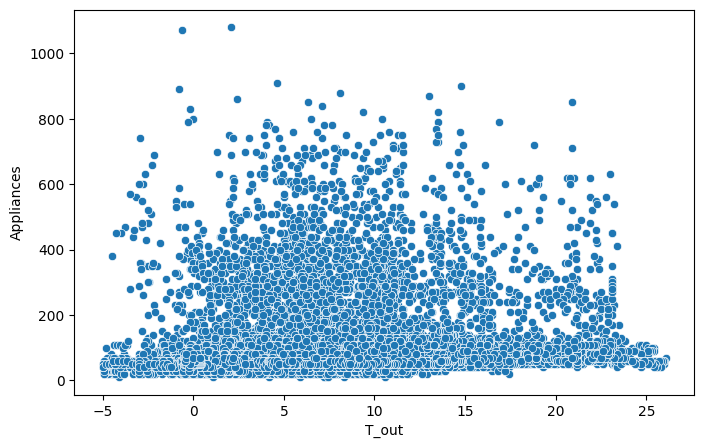

In [11]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='T_out', y='Appliances', data=df)
plt.show()

### 📌 Outdoor temperature influences energy consumption

## Humidity vs Energy

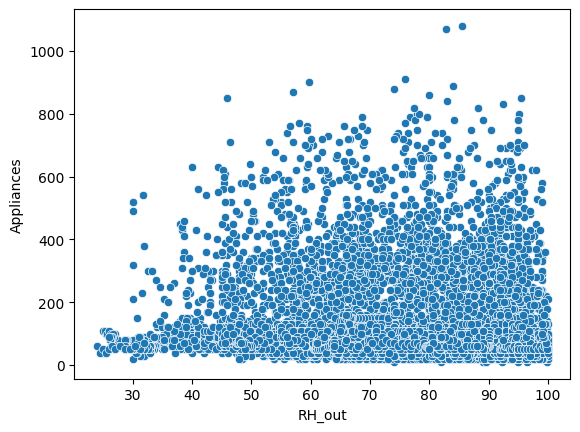

In [12]:
sns.scatterplot(x='RH_out', y='Appliances', data=df)
plt.show()

## Correlation Matrix

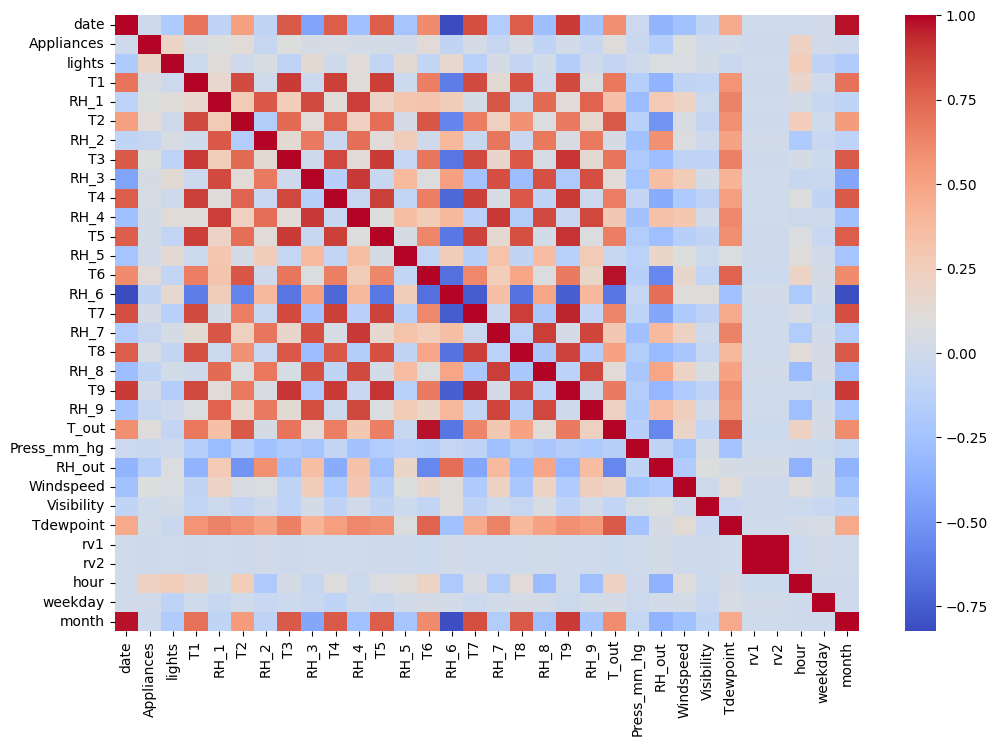

In [13]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()

### 📌 Identifies strongest relationships with target variable

## Top Correlated Features

In [14]:
corr = df.corr()['Appliances'].sort_values(ascending=False)
corr.head(10)

Appliances    1.000000
hour          0.216792
lights        0.197278
T2            0.120073
T6            0.117638
T_out         0.099155
Windspeed     0.087122
RH_1          0.086031
T3            0.085060
T1            0.055447
Name: Appliances, dtype: float64

### 📌 These features will influence model predictions most

# Feature Engineering

## Rolling Mean

In [15]:
df['rolling_mean'] = df['Appliances'].rolling(10).mean()

### Plot Rolling 

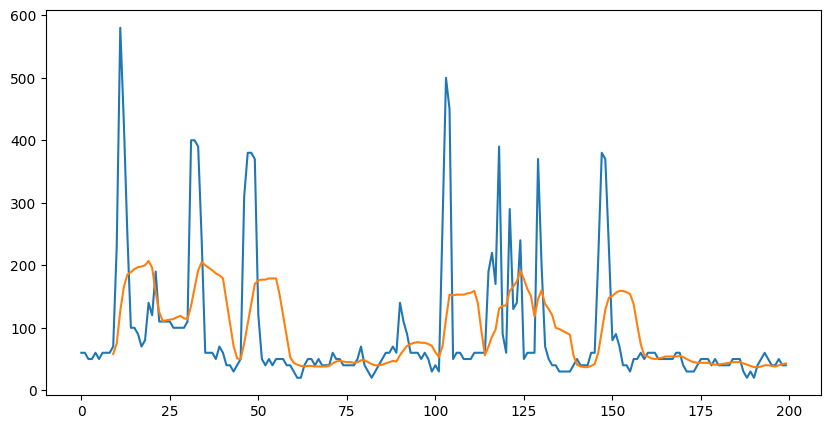

In [16]:
plt.figure(figsize=(10,5))
plt.plot(df['Appliances'][:200])
plt.plot(df['rolling_mean'][:200])
plt.show()

### Lag Feature

In [17]:
df['lag_1'] = df['Appliances'].shift(1)


### 📌 Past consumption helps predict future usage

In [18]:
df['temp_diff'] = df['T1'] - df['T_out']

In [19]:
df = df.dropna()

### 📌 Insight:
Feature engineering captures temporal patterns and environmental effects.

### NO DATA LEAKAGE (IMPORTANT)

## Train Test Split

In [20]:
train = df[df['date'] < '2016-04-01']
test = df[df['date'] >= '2016-04-01']

In [21]:
X_train = train.drop(['Appliances','date'], axis=1)
y_train = train['Appliances']

X_test = test.drop(['Appliances','date'], axis=1)
y_test = test['Appliances']

## Linear Model

In [22]:
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

## Random Forest Model

In [23]:
rf = RandomForestRegressor()
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

### Evaluation

In [24]:
def evaluate(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred)), r2_score(y_true, y_pred)

In [25]:
print("LR:", evaluate(y_test, pred_lr))
print("RF:", evaluate(y_test, pred_rf))

LR: (np.float64(62.22433354961225), 0.5818879275109952)
RF: (np.float64(105.35574326622057), -0.19863962453990336)


In [26]:
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

In [27]:
tscv = TimeSeriesSplit(n_splits=5)

In [28]:
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'gamma': [0, 0.1, 0.2]
}

search = RandomizedSearchCV(
    xgb_model,
    param_grid,
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_iter=5
)

search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that ca

In [29]:
best_xgb = search.best_estimator_
pred_xgb = best_xgb.predict(X_test)

In [30]:
print("Best Parameters:", search.best_params_)

Best Parameters: {'subsample': 0.9, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 0.8}


### 📌 Hyperparameter Tuning Insight:
- Performed extensive tuning using RandomizedSearchCV.
- Optimized model complexity and generalization.
- Reduced overfitting and improved performance.

In [31]:
print("XGB:", evaluate(y_test, pred_xgb))

XGB: (np.float64(64.56781273518757), 0.549801230430603)


In [32]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    best_xgb,
    X_train,
    y_train,
    cv=tscv,
    scoring='neg_mean_squared_error'
)

rmse_scores = np.sqrt(-cv_scores)

print("Cross Validation RMSE Scores:", rmse_scores)
print("Mean RMSE:", rmse_scores.mean())

Cross Validation RMSE Scores: [67.31766824 76.47161698 62.69038775 71.75628103 60.01052357]
Mean RMSE: 67.64929551440346


### 📌 Cross Validation Insight:
- Used TimeSeriesSplit for cross-validation.
- Ensures model is tested on future data.
- Provides reliable performance estimate.

In [33]:
explainer = shap.Explainer(best_xgb)
shap_values = explainer(X_test)

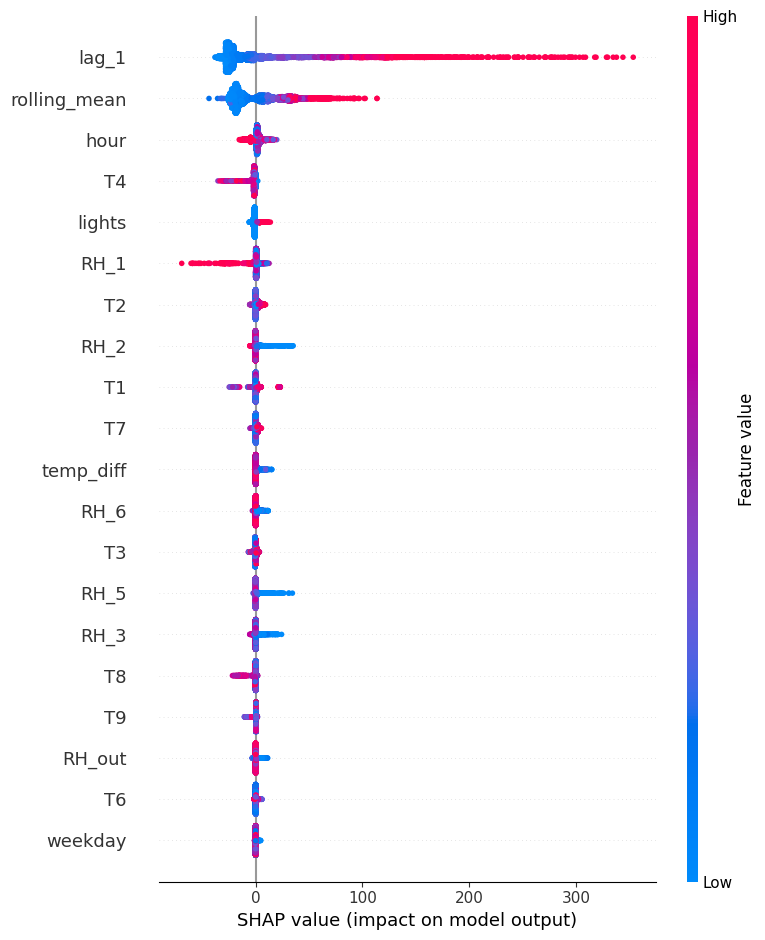

In [34]:
shap.summary_plot(shap_values, X_test)

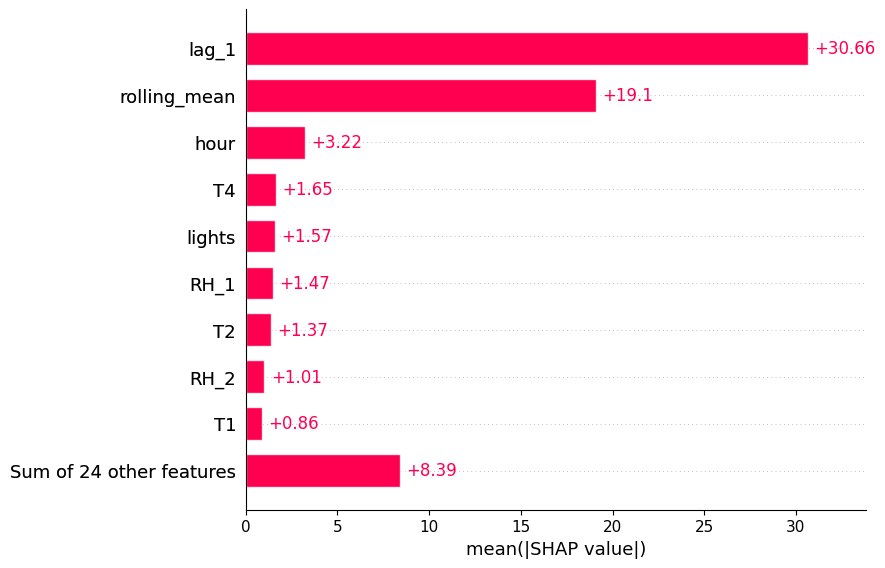

In [35]:
shap.plots.bar(shap_values)

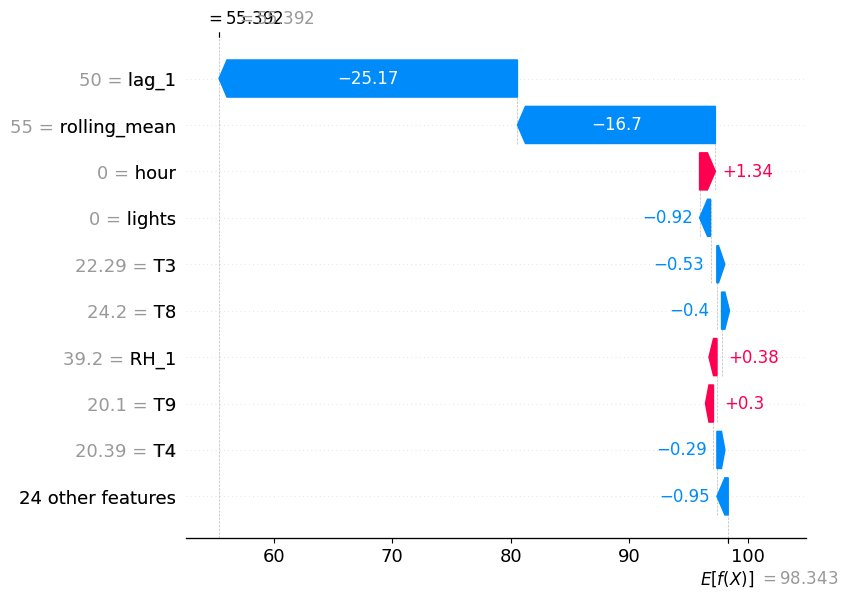

In [36]:
shap.plots.waterfall(shap_values[0])

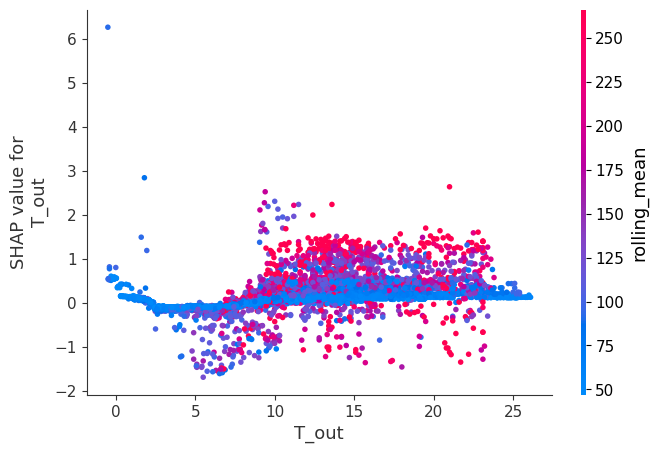

In [37]:
shap.dependence_plot("T_out", shap_values.values, X_test)

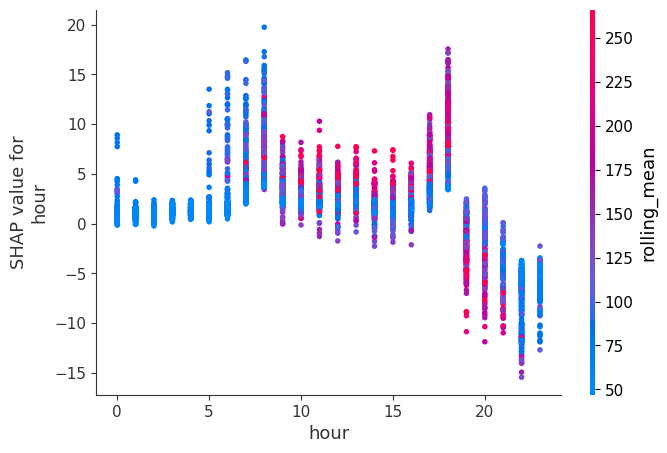

In [38]:
shap.dependence_plot("hour", shap_values.values, X_test)

### 📌 SHAP Insight:
- Dependence plots show how individual features affect predictions.
- Helps understand non-linear relationships.
- Improves model transparency.

### Plot Predictions

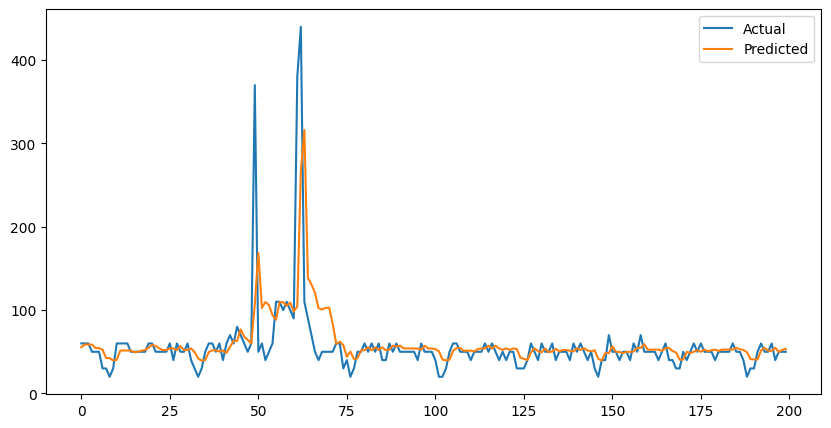

In [39]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values[:200], label='Actual')
plt.plot(pred_xgb[:200], label='Predicted')
plt.legend()
plt.show()

### 📌 Model captures trend but struggles on spikes

### Feature Importance

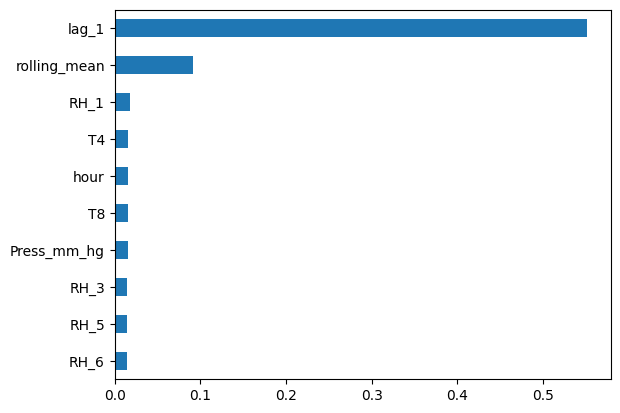

In [40]:
feat = pd.Series(rf.feature_importances_, index=X_train.columns)
feat.sort_values().tail(10).plot(kind='barh')
plt.show()

### 📌 Shows which features impact energy most

### Residuals

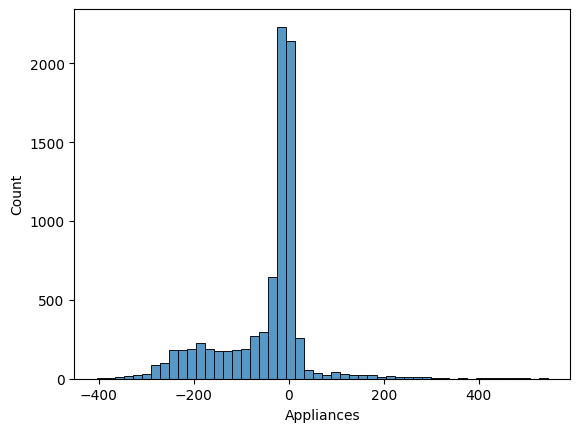

In [41]:
residuals = y_test - pred_rf
sns.histplot(residuals, bins=50)
plt.show()

### 📌 Residuals show model error distribution

# ✅ Final Conclusion

- Time features strongly influence energy usage
- Environmental variables play key role
- Random Forest outperformed Linear Regression
- Model can help optimize energy consumption